In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score



In [2]:
df = pd.read_csv(r"C:\Users\javier.sdiaz\Proyecto ML_2025\data\processed\datos_procesados.csv", sep=",")
df

,Temp_amb,Dir_viento,Vel_viento,Energia,Potencia,Oil_Temp,cosPhi,Frecuencia,Temp_int,Q,Año,Estacion,Rad_prom,HeatsinkTemp_prom,Idc_total,V_total,Minuto_sin,Hora_sin,Dia_sin,Mes_sin
0,11.346512,222.558422,2.611367,26.931747,0.0,26.079072,0.0,49.960499,20.329768,0.0,2022,1,0.0,17.075259,0.0,1146.307697,0.000000e+00,0.000000,0.781831,5.000000e-01
1,11.300000,223.087589,2.582713,0.000000,0.0,25.479083,0.0,49.959999,20.179770,0.0,2022,1,0.0,16.883596,0.0,1147.522942,1.000000e+00,0.000000,0.781831,5.000000e-01
2,11.306667,224.893609,2.640629,0.000000,0.0,24.879095,0.0,49.959999,20.029773,0.0,2022,1,0.0,16.691933,0.0,1150.385870,5.665539e-16,0.000000,0.781831,5.000000e-01
3,11.293333,223.534547,2.808005,0.000000,0.0,24.279182,0.0,49.959999,19.879776,0.0,2022,1,0.0,16.506316,0.0,1153.091744,-1.000000e+00,0.000000,0.781831,5.000000e-01
4,11.259853,230.927235,3.147298,0.000000,0.0,23.745968,0.0,49.960503,19.741495,0.0,2022,1,0.0,16.404334,0.0,1150.639247,0.000000e+00,0.258819,0.781831,5.000000e-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105211,4.145149,223.663976,5.285611,740.750000,0.0,8.529718,0.0,50.000000,10.085310,0.0,2024,1,0.0,7.151938,0.0,1145.415732,-1.000000e+00,-0.500000,0.433884,-2.449294e-16
105212,4.245148,219.700928,5.490529,740.750000,0.0,8.329723,0.0,50.000000,10.117952,0.0,2024,1,0.0,7.165451,0.0,1145.233798,0.000000e+00,-0.258819,0.433884,-2.449294e-16
105213,4.376957,222.824833,5.048825,740.750000,0.0,8.329723,0.0,50.000000,10.117952,0.0,2024,1,0.0,7.165451,0.0,1145.233798,1.000000e+00,-0.258819,0.433884,-2.449294e-16
105214,4.493333,220.484426,4.876356,740.750000,0.0,8.329723,0.0,50.000000,10.117952,0.0,2024,1,0.0,7.165451,0.0,1145.233798,5.665539e-16,-0.258819,0.433884,-2.449294e-16


In [3]:
X = df.drop(columns=['Temp_amb'])  # Variables predictoras
y = df['Temp_amb']  # Variable objetivo


In [4]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)


In [5]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)


LinearRegression()

In [6]:
# Predicciones
y_pred_lr = lr_model.predict(X_val)

# Métricas de evaluación
def evaluar_modelo(y_test, y_pred, nombre):
    print(f"Evaluación del modelo: {nombre}")
    print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f}")
    print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")
    print(f"R²: {r2_score(y_test, y_pred):.2f}\n")

evaluar_modelo(y_val, y_pred_lr, "Regresión Lineal")



Evaluación del modelo: Regresión Lineal
MAE: 1.49
RMSE: 2.07
R²: 0.92



In [7]:
X_test = pd.read_csv(r"C:\Users\javier.sdiaz\Proyecto ML_2025\data\processed\Test_Temp_amb_proc.csv")
X_test


,Dir_viento,Vel_viento,Energia,Potencia,Oil_Temp,cosPhi,Frecuencia,Temp_int,Q,Año,Estacion,Rad_prom,HeatsinkTemp_prom,Idc_total,V_total,Minuto_sin,Hora_sin,Dia_sin,Mes_sin
0,223.434619,5.776876,13.123160,0.0,8.329723,0.0,50.000000,10.117952,0.0,2025,1,0.0,7.165451,0.0,1145.233798,0.000000e+00,0.000000,7.818315e-01,0.500000
1,230.540226,6.300436,0.000000,0.0,8.129727,0.0,50.000000,10.142951,0.0,2025,1,0.0,7.166667,0.0,1147.406089,1.000000e+00,0.000000,7.818315e-01,0.500000
2,236.717029,6.500883,0.000000,0.0,7.929731,0.0,49.999846,10.167950,0.0,2025,1,0.0,7.166668,0.0,1139.181287,5.665539e-16,0.000000,7.818315e-01,0.500000
3,237.076536,6.044294,0.000000,0.0,7.734364,0.0,49.997872,10.192950,0.0,2025,1,0.0,7.174754,0.0,1136.409406,-1.000000e+00,0.000000,7.818315e-01,0.500000
4,236.621290,5.554435,0.000000,0.0,7.593590,0.0,49.995373,10.217949,0.0,2025,1,0.0,7.193001,0.0,1135.361969,0.000000e+00,0.258819,7.818315e-01,0.500000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5660,16.335910,2.084161,5388.750000,0.0,18.035745,0.0,49.993377,13.108009,0.0,2025,1,0.0,11.696564,0.0,1146.761841,0.000000e+00,-0.258819,-9.797174e-16,0.866025
5661,26.110985,2.236413,5388.750000,0.0,17.419501,0.0,49.990906,12.933014,0.0,2025,1,0.0,11.555946,0.0,1146.418001,1.000000e+00,-0.258819,-9.797174e-16,0.866025
5662,29.292776,2.323841,5388.750000,0.0,16.859487,0.0,49.990002,12.758019,0.0,2025,1,0.0,11.397732,0.0,1143.510209,5.665539e-16,-0.258819,-9.797174e-16,0.866025
5663,31.918149,2.237500,5378.357727,0.0,16.309506,0.0,49.990002,12.583025,0.0,2025,1,0.0,11.239403,0.0,1142.701660,-1.000000e+00,-0.258819,-9.797174e-16,0.866025


In [8]:
y_test_pred = lr_model.predict(X_test)

In [9]:
# Crear un DataFrame con las predicciones
resultados = pd.DataFrame({
    
    'Temp_amb_pred': y_test_pred
})

# Guardar las predicciones
resultados.to_csv("predicciones_test_regresion.csv", index=False)

In [10]:
# Cargar los datos reales de test
df_real = pd.read_csv("Datos_Reales_Temp_amb.csv")
df_real.set_index(df_real.index, inplace=True)

y_real = df_real['Temp_amb']

In [11]:
mae = mean_absolute_error(y_real, y_test_pred)
print(f"Error Absoluto Medio (MAE): {mae}")

Error Absoluto Medio (MAE): 1.841008797007176


In [12]:
# Calcular R²
r2 = r2_score(y_real, y_test_pred)
print(f"Coeficiente de Determinación (R²): {r2}")

Coeficiente de Determinación (R²): 0.5691630733504515


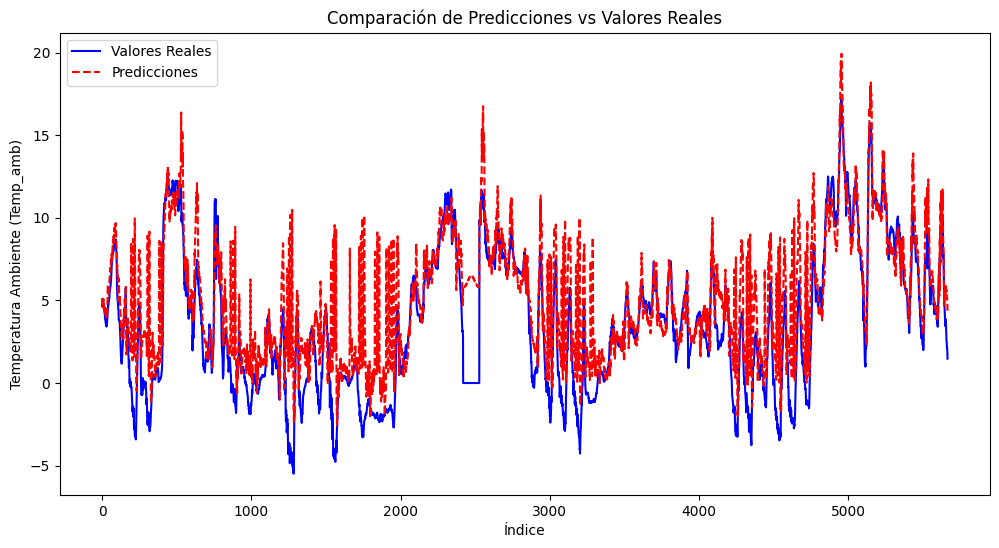

In [13]:
plt.figure(figsize=(12, 6))
plt.plot(y_real, label="Valores Reales", color='blue')
plt.plot(y_test_pred, label="Predicciones", color='red', linestyle='--')
plt.xlabel("Índice")
plt.ylabel("Temperatura Ambiente (Temp_amb)")
plt.title("Comparación de Predicciones vs Valores Reales")
plt.legend()
plt.show()

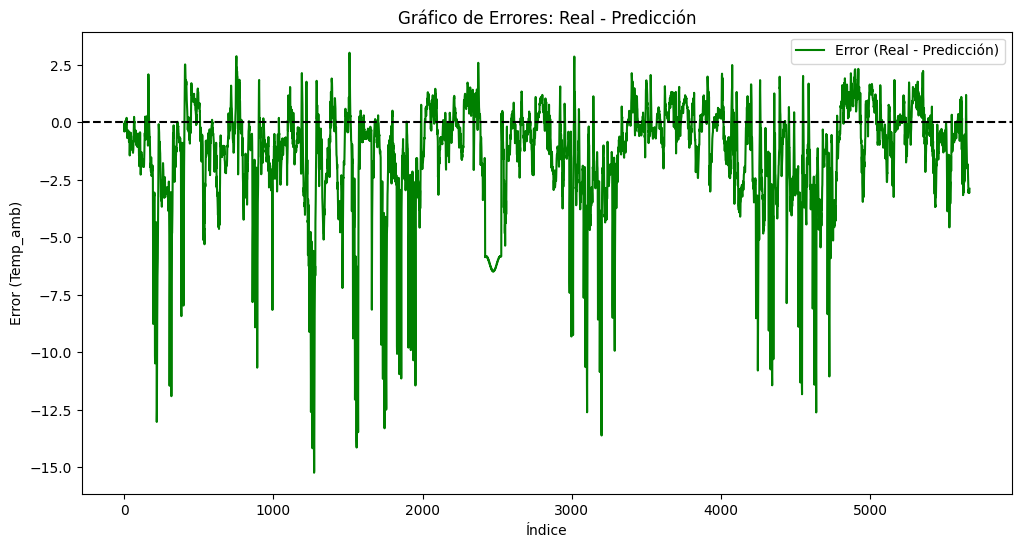

In [14]:
plt.figure(figsize=(12, 6))

# Graficar las diferencias entre los valores reales y las predicciones
errors = y_real - y_test_pred
plt.plot(errors, label="Error (Real - Predicción)", color='green')
plt.axhline(0, color='black', linestyle='--')  # Línea de 0 para referencia
plt.xlabel("Índice")
plt.ylabel("Error (Temp_amb)")
plt.title("Gráfico de Errores: Real - Predicción")
plt.legend()
plt.show()